### ***Hyperparameter, GridSearchCV, RandomSearchCV***


### ***German Credit Analysis***

### ***Context***

*To minimize loss from the bank’s perspective, the bank needs a decision rule regarding whom to approve the loan and whom not to. An applicant’s demographic and socio-economic profiles are considered by loan managers before a decision is taken regarding his/her loan application. In this dataset, each entry represents a person who takes credit from a bank. Each person is classified as a good or bad credit risk according to the set of attributes.*

### ***Objective*** 
*The objective is to build a model to predict whether a person would default or not. In this dataset, the target variable is 'Risk'.*

### ***Dataset Description***
- *`Age` (Numeric: Age in years)*
- *`Sex` (Categories: male, female)*
- *`Job` (Categories : 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)*
- *`Housing` (Categories: own, rent, or free)*
- *`Saving accounts` (Categories: little, moderate, quite rich, rich)*
- *`Checking account` (Categories: little, moderate, rich)*
- *`Credit amount` (Numeric: Amount of credit in DM - Deutsche Mark)*
- *`Duration` (Numeric: Duration for which the credit is given in months)*
- *`Purpose` (Categories: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others)*
- *`Risk` (0 - Person is not at risk, 1 - Person is at risk(defaulter))*

### ***Importing libraries***

In [1]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To be used for missing value imputation
from sklearn.impute import SimpleImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

### ***Dataset Load and Review***

In [2]:
# Loading the dataset
german = pd.read_csv("data/33_German_Credit.csv")

In [3]:
# Checking the number of rows and columns in the data
german.shape

(1000, 10)

In [4]:
data = german.copy()

In [5]:
# let's view the first 5 rows of the data
data.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


In [6]:
# let's view the last 5 rows of the data
data.tail()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,0
996,40,male,3,own,little,little,3857,30,car,0
997,38,male,2,own,little,NaN,804,12,radio/TV,0
998,23,male,2,free,little,little,1845,45,radio/TV,1
999,27,male,2,own,moderate,moderate,4576,45,car,0


In [7]:
# let's check the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


- ***There are total 10 columns and 1,000 observations in the dataset***
- ***We have only three continuous variables - `Age`, `Credit Amount`, and `Duration`.***
- ***All other variables are categorical.***
- ***`Saving accounts` and `Checking account` have missing values***

In [8]:
# let's check for duplicate values in the data
data.duplicated().sum()

np.int64(0)

In [9]:
# let's check for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

Age                 0.000
Sex                 0.000
Job                 0.000
Housing             0.000
Saving accounts    18.300
Checking account   39.400
Credit amount       0.000
Duration            0.000
Purpose             0.000
Risk                0.000
dtype: float64

- ***`Saving account` has 18% values missing***
- ***`Checking account` has 39% values missing***

***Let's check the number of unique values in each column***

In [10]:
data.nunique()

Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
Risk                  2
dtype: int64

- ***As we saw earlier, We have only three continuous variables - Age, Credit Amount and Duration.***
- ***All other variables are categorical***

In [11]:
# let's view the statistical summary of the numerical columns in the data
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.000,35.546,11.375,19.000,27.000,33.000,42.000,75.000
Job,1000.000,1.904,0.654,0.000,2.000,2.000,2.000,3.000
Credit amount,1000.000,3271.258,2822.737,250.000,1365.500,2319.500,3972.250,18424.000
Duration,1000.000,20.903,12.059,4.000,12.000,18.000,24.000,72.000
Risk,1000.000,0.300,0.458,0.000,0.000,0.000,1.000,1.000


- ***Average Age of Customer is 35 and Median is 33. Min Age is 19 and Max is 75 years***
- ***Average Credit Amount is approx 3271 and Median is 2319, data is right skewed. Min is 250 and max is 18424 which is way higher than Q3 which is 3972.*** 
- ***Average Duration is 21 years, Median is 18. Min is 4 and Max is 72, which is way higher***

***Checking the value count for each category of categorical variables*** 

In [12]:
# Making a list of all catrgorical variables
cat_col = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
    "Risk",
]

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts(1))
    print("-" * 40)

Sex
male     0.690
female   0.310
Name: proportion, dtype: float64
----------------------------------------
Job
2   0.630
1   0.200
3   0.148
0   0.022
Name: proportion, dtype: float64
----------------------------------------
Housing
own    0.713
rent   0.179
free   0.108
Name: proportion, dtype: float64
----------------------------------------
Saving accounts
little       0.738
moderate     0.126
quite rich   0.077
rich         0.059
Name: proportion, dtype: float64
----------------------------------------
Checking account
little     0.452
moderate   0.444
rich       0.104
Name: proportion, dtype: float64
----------------------------------------
Purpose
car                   0.337
radio/TV              0.280
furniture/equipment   0.181
business              0.097
education             0.059
repairs               0.022
domestic appliances   0.012
vacation/others       0.012
Name: proportion, dtype: float64
----------------------------------------
Risk
0   0.700
1   0.300
Name: proporti

- ***`Sex` 69% are Male and 31 are Female***
- ***`Job` Majority of Job is `Skilled` with 63%, followed by `Unskilled and resident` which is 20%***
- ***`Housing` 71% own their house, 17% live on rent***
- ***`Saving accounts` 74% have little savings in their Savings Account, followed by moderate Savings which is 13%***
- ***`Checking account` This is more evenly distributed between moderate (44%) and little (45%)***
- ***`Purpose` - Most of the customers took loan for big item like Car (33.7%), 28% took for small items like radio/TV***
- ***`Risk` - 30% of customers are at risk***

### ***Data Preparation for Modeling***

In [13]:
df = data.copy()

In [14]:
X = df.drop(["Risk"], axis=1)
y = df["Risk"]

***Data Split into Training, Validation and Test set: In 2 steps***
- ***First Split the data into Temp and Test***
- ***Then Split the Temp into Train and Val***

In [15]:
# splitting the data into temporary and test set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

# then we split the temporary set into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(600, 9) (200, 9) (200, 9)


### ***Missing-Value Treatment***

* ***We will use mode to impute missing values in Saving accounts and Checking account column.***

In [16]:
# Let's impute the missing values
imp_mode = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
cols_to_impute = ["Saving accounts", "Checking account"]

# fit and transform the imputer on train data
X_train[cols_to_impute] = imp_mode.fit_transform(X_train[cols_to_impute]) # using fit_transform for training data

# Transform on validation and test data
X_val[cols_to_impute] = imp_mode.transform(X_val[cols_to_impute]) # using transform for validation data

# fit and transform the imputer on test data
X_test[cols_to_impute] = imp_mode.transform(X_test[cols_to_impute]) # using transform for test data

In [17]:
# Checking missing values in train, validation, and test sets
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_val:")
print(X_val.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

Missing values in X_val:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

Missing values in X_test:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [18]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)

In [19]:
# checking the class balance of target variable
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Risk
0   0.700
1   0.300
Name: proportion, dtype: float64
Risk
0   0.700
1   0.300
Name: proportion, dtype: float64
Risk
0   0.700
1   0.300
Name: proportion, dtype: float64


### ***Model evaluation criterion***

#### ***We will be using Recall as a metric for our model performance because here company could face 2 types of losses***
- ***Could Give loan to defaulters - Loss of money***
- ***Not give Loan to non-defaulters - Loss of opportunity***

#### ***Which Loss is greater?***
* ***Giving loan to defaulters i.e Predicting a person not at risk, while actually person is at risk of making a default.***

#### ***How to reduce this loss i.e need to reduce False Negatives?***
* ***Company wants recall to be maximized i.e. we need to reduce the number of false negatives.***

In [20]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)  
    
    # Setting number of splits equal to 5
    cv_result = cross_val_score(estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold)
    
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, round(cv_result.mean(), 3)))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, round(scores, 3)))


Cross-Validation Performance:

Bagging: 0.244
Random forest: 0.244
GBM: 0.25
Adaboost: 0.183
Xgboost: 0.322
dtree: 0.433

Validation Performance:

Bagging: 0.283
Random forest: 0.317
GBM: 0.317
Adaboost: 0.2
Xgboost: 0.433
dtree: 0.317


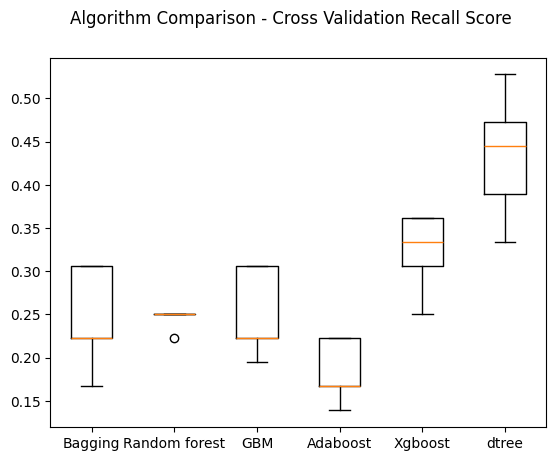

In [21]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison - Cross Validation Recall Score")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

- ***We can see that the decision tree is giving the highest cross-validated recall followed by xgboost***
- ***The boxplot shows that the performance of decision tree and xgboost is consistent and their performance on the validation set is also good***
- ***We will tune the best two models i.e. decision tree and xgboost and see if the performance improves*** 

***Hyperparameter Tuning decision tree and xgboost models using GridSearchCV and RandomizedSearchCV***

***Helper Functions***

In [22]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [23]:
def confusion_matrix_sklearn(model, predictors, y_actual):
    """
    Generates a labeled confusion matrix heatmap.

    Parameters:
    - model: trained classifier
    - predictors: feature matrix to predict on (can be train, test, or validation)
    - y_actual: true labels corresponding to X
    """
    # Predict labels
    y_predict = model.predict(predictors)

    # Compute confusion matrix
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index=["Actual - No", "Actual - Yes"],
                             columns=["Predicted - No", "Predicted - Yes"])

    # Annotate with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]
    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(cm.shape)

    # Plot heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

### ***Decision Tree***

### ***GridSearchCV***

In [24]:
# Creating pipeline
model = DecisionTreeClassifier(random_state=1)

# Parameter grid to pass in GridSearchCV
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, None],
    "min_samples_split": [2, 4, 7, 10, 15],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print("Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_))

Best Parameters:{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2} 
Score: 0.40555555555555556


In [25]:
# Creating new pipeline with best parameters
dtree_tuned1 = DecisionTreeClassifier(random_state=1, criterion="gini", max_depth=None, min_samples_split=2)

# Fit the model on training data
dtree_tuned1.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# Calculating different metrics on train set
dtree_grid_train = model_performance_classification_sklearn(dtree_tuned1, X_train, y_train)

print("Training performance:")
dtree_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [27]:
# Calculating different metrics on validation set
dtree_grid_val = model_performance_classification_sklearn(dtree_tuned1, X_val, y_val)
print("Validation performance:")
dtree_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.595,0.317,0.322,0.319


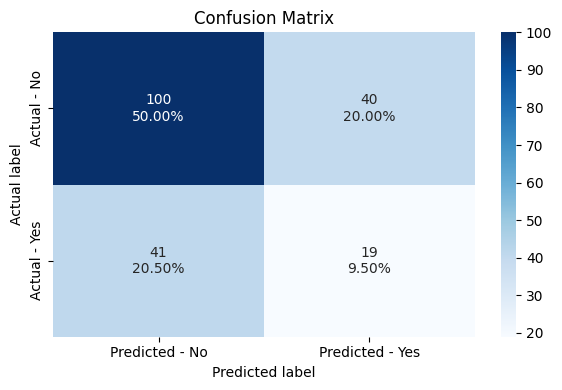

In [28]:
# creating confusion matrix
confusion_matrix_sklearn(dtree_tuned1, X_val, y_val)

- ***The validation recall has same performance to the validation recall on model with default parameters***
- ***The tuned decision tree model is overfitting the training data***

### ***RandomizedSearchCV***

In [29]:
# Creating pipeline
model = DecisionTreeClassifier(random_state=1)

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, None],
    "min_samples_split": [2, 4, 7, 10, 15],
}
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=1,
)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:".format(randomized_cv.best_params_, randomized_cv.best_score_))


Best parameters are {'min_samples_split': 2, 'max_depth': None, 'criterion': 'entropy'} with CV score=0.36666666666666664:


In [30]:
# Using Best Parameters
dtree_tuned2 = DecisionTreeClassifier(random_state=1, criterion="entropy", max_depth=None, min_samples_split=2)

# Fit the model on training data
dtree_tuned2.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
# Calculating different metrics on train set
dtree_random_train = model_performance_classification_sklearn(dtree_tuned2, X_train, y_train)

print("Training performance:")
dtree_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,1.000,1.000,1.000,1.000


In [32]:
# Calculating different metrics on validation set
dtree_random_val = model_performance_classification_sklearn(dtree_tuned2, X_val, y_val)
print("Validation performance:")
dtree_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.575,0.450,0.342,0.388


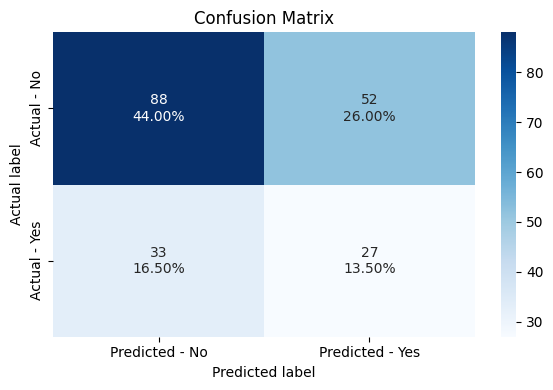

In [33]:
# creating confusion matrix
confusion_matrix_sklearn(dtree_tuned2, X_val, y_val)

***Recall Validation Score is better, but still model is overfitting***

### ***XGBoost***

### ***GridSearchCV***

In [34]:
%%time 

#defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

#Parameter grid to pass in GridSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}


# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

#Fitting parameters in GridSeachCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Best parameters are {'gamma': 0, 'learning_rate': 0.01, 'max_depth': np.int64(1), 'n_estimators': np.int64(50), 'reg_lambda': 5, 'scale_pos_weight': 5, 'subsample': 0.8} with CV score=1.0:
CPU times: total: 4.2 s
Wall time: 35.9 s


In [35]:
# building model with best parameters
xgb_tuned1 = XGBClassifier(
    random_state=1,
    n_estimators=50,
    scale_pos_weight=10,
    subsample=0.8,
    learning_rate=0.01,
    gamma=0,
    eval_metric="logloss",
    reg_lambda=5,
    max_depth=1,
)

# Fit the model on training data
xgb_tuned1.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [36]:
# Calculating different metrics on train set
xgboost_grid_train = model_performance_classification_sklearn(xgb_tuned1, X_train, y_train)

print("Training performance:")
xgboost_grid_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.300,1.000,0.300,0.462


In [37]:
# Calculating different metrics on validation set
xgboost_grid_val = model_performance_classification_sklearn(xgb_tuned1, X_val, y_val)

print("Validation performance:")
xgboost_grid_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.300,1.000,0.300,0.462


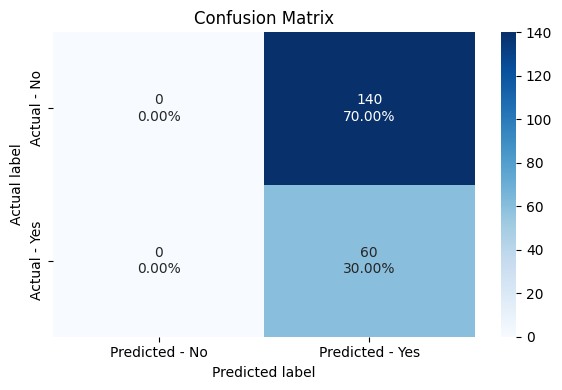

In [38]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned1, X_val, y_val)

***Model is not good since its predicting everyone to default***

### ***RandomizedSearchCV***

In [39]:
%%time

# defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

# Parameter grid to pass in RandomizedSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
xgb_tuned2 = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
xgb_tuned2.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(xgb_tuned2.best_params_,xgb_tuned2.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 5, 'reg_lambda': 10, 'n_estimators': np.int64(50), 'max_depth': np.int64(3), 'learning_rate': 0.01, 'gamma': 3} with CV score=1.0:
CPU times: total: 297 ms
Wall time: 778 ms


In [40]:
# building model with best parameters
xgb_tuned2 = XGBClassifier(
    random_state=1,
    n_estimators=50,
    scale_pos_weight=10,
    gamma=1,
    subsample=0.9,
    learning_rate=0.01,
    eval_metric="logloss",
    max_depth=1,
    reg_lambda=5,
)
# Fit the model on training data
xgb_tuned2.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [41]:
# Calculating different metrics on train set
xgboost_random_train = model_performance_classification_sklearn(xgb_tuned2, X_train, y_train)

print("Training performance:")
xgboost_random_train

Training performance:


,Accuracy,Recall,Precision,F1
0,0.300,1.000,0.300,0.462


In [42]:
# Calculating different metrics on validation set
xgboost_random_val = model_performance_classification_sklearn(xgb_tuned2, X_val, y_val)

print("Validation performance:")
xgboost_random_val

Validation performance:


,Accuracy,Recall,Precision,F1
0,0.300,1.000,0.300,0.462


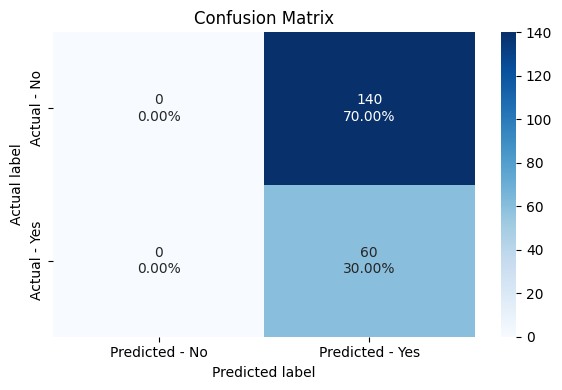

In [43]:
# creating confusion matrix
confusion_matrix_sklearn(xgb_tuned2, X_val, y_val)

***Model is not good as its predicting everyone will default***

### ***Comparing models from GridsearchCV and RandomisedsearchCV***

In [44]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree_grid_train.T,
        dtree_random_train.T,
        xgboost_grid_train.T,
        xgboost_random_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Tuned with Grid search",
    "Decision Tree Tuned with Random search",
    "Xgboost Tuned with Grid search",
    "Xgboost Tuned with Random Search",
]
print("Training performance comparison:")
models_train_comp_df.T

Training performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree Tuned with Grid search,1.000,1.000,1.000,1.000
Decision Tree Tuned with Random search,1.000,1.000,1.000,1.000
Xgboost Tuned with Grid search,0.300,1.000,0.300,0.462
Xgboost Tuned with Random Search,0.300,1.000,0.300,0.462


In [45]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
        dtree_grid_val.T,
        dtree_random_val.T,
        xgboost_grid_val.T,
        xgboost_random_val.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Decision Tree Tuned with Grid search",
    "Decision Tree Tuned with Random search",
    "Xgboost Tuned with Grid search",
    "Xgboost Tuned with Random Search",
]
print("Validation performance comparison:")
models_val_comp_df.T

Validation performance comparison:


,Accuracy,Recall,Precision,F1
Decision Tree Tuned with Grid search,0.595,0.317,0.322,0.319
Decision Tree Tuned with Random search,0.575,0.450,0.342,0.388
Xgboost Tuned with Grid search,0.300,1.000,0.300,0.462
Xgboost Tuned with Random Search,0.300,1.000,0.300,0.462


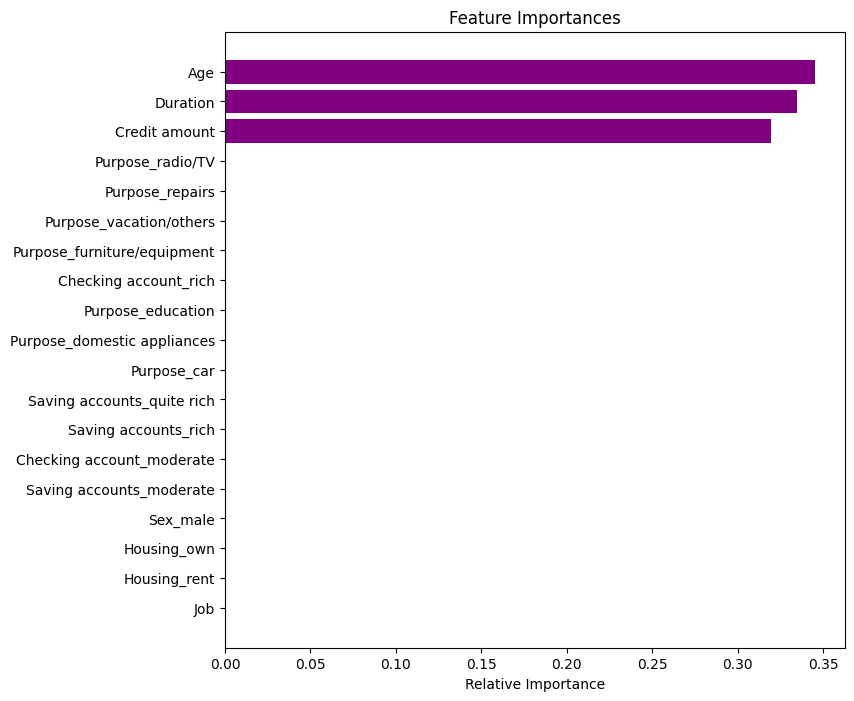

In [46]:
feature_names = X_train.columns
importances = xgb_tuned1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Age and duration are the two most important variables which make sense as these variable play an important role in taking/returning credit.

### ***Pipelines for productionizing the model***

### ***Column Transformer***
- ***We know that we can use pipelines to standardize the model building, but the steps in a pipeline are applied to each and every variable - how can we personalize the pipeline to perform different processing on different columns***

- ***Column transformer allows different columns or column subsets of the input to be transformed separately and the features generated by each transformer will be concatenated to form a single feature space. This is useful for heterogeneous or columnar data, to combine several feature extraction mechanisms or transformations into a single transformer.***

***We will create 2 different pipelines, one for numerical columns and one for categorical columns***
- ***For numerical columns, we will do missing value imputation as pre-processing***
- ***For categorical columns, we will do one hot encoding and missing value imputation as pre-processing***

In [47]:
# creating a list of numerical variables
numerical_features = ["Age", "Credit amount", "Duration"]

# creating a transformer for numerical variables, which will apply simple imputer on the numerical variables
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

# creating a list of categorical variables
categorical_features = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose",
]

# creating a transformer for categorical variables, which will first apply simple imputer and
# then do one hot encoding for categorical variables
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# handle_unknown = "ignore", allows model to handle any unknown category in the test data

# combining categorical transformer and numerical transformer using a column transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="passthrough",
)
# remainder = "passthrough" has been used, it will allow variables that are present in original data
# but not in "numerical_columns" and "categorical_columns" to pass through the column transformer without any changes

In [48]:
# Separating target variable and other variables
X = data.drop("Risk", axis=1)
Y = data["Risk"]

In [49]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1, stratify=Y)

print(X_train.shape, X_test.shape)

(700, 9) (300, 9)


In [50]:
# Creating new pipeline with best parameters
model = Pipeline(
    steps=[
        ("pre", preprocessor),
        (
            "XGB",
            XGBClassifier(
                random_state=1,
                n_estimators=50,
                scale_pos_weight=10,
                subsample=0.8,
                learning_rate=0.01,
                gamma=0,
                eval_metric="logloss",
                reg_lambda=5,
                max_depth=1,
            ),
        ),
    ]
)
# Fit the model on training data
model.fit(X_train, y_train)
model.get_params()

{'memory': None,
 'steps': [('pre', ColumnTransformer(remainder='passthrough',
                     transformers=[('num',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='median'))]),
                                    ['Age', 'Credit amount', 'Duration']),
                                   ('cat',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehot',
                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                    ['Sex', 'Job', 'Housing', 'Saving accounts',
                                     'Checking account', 'Purpose'])])),
  ('XGB',
   XGBClassifier(base_score=None, booster=None, callbacks=None,
                 colsample_bylevel=None, colsample_bynode=No